### Introduction to AlexNet

AlexNet, a pioneering convolutional neural network (CNN) developed by Alex Krizhevsky under the guidance of Geoffrey Hinton, revolutionized computer vision by winning the 2012 ImageNet Large Scale Visual Recognition Challenge (ILSVRC). Its breakthrough performance far surpassed that of conventional machine learning methods.

The success of AlexNet sparked a wave of innovation in deep learning, paving the way for more advanced architectures such as VGGNet and GoogLeNet.

In the 2012 ILSVRC, AlexNet recorded a top-5 error rate of **15.3%**, corresponding to a top-5 accuracy of **57.1%**—a landmark achievement in image classification that highlighted the power of deep neural networks. In contrast, traditional algorithms at the time achieved significantly lower accuracy on the same task.

![AlexNet Architecture](https://raw.githubusercontent.com/blurred-machine/Data-Science/master/Deep%20Learning%20SOTA/img/alexnet2.png)

*This Jupyter notebook is designed to help learners explore and understand the AlexNet architecture in depth.*

Using cuda
Original image size: (260, 246) → will be cropped/resized to 227x227


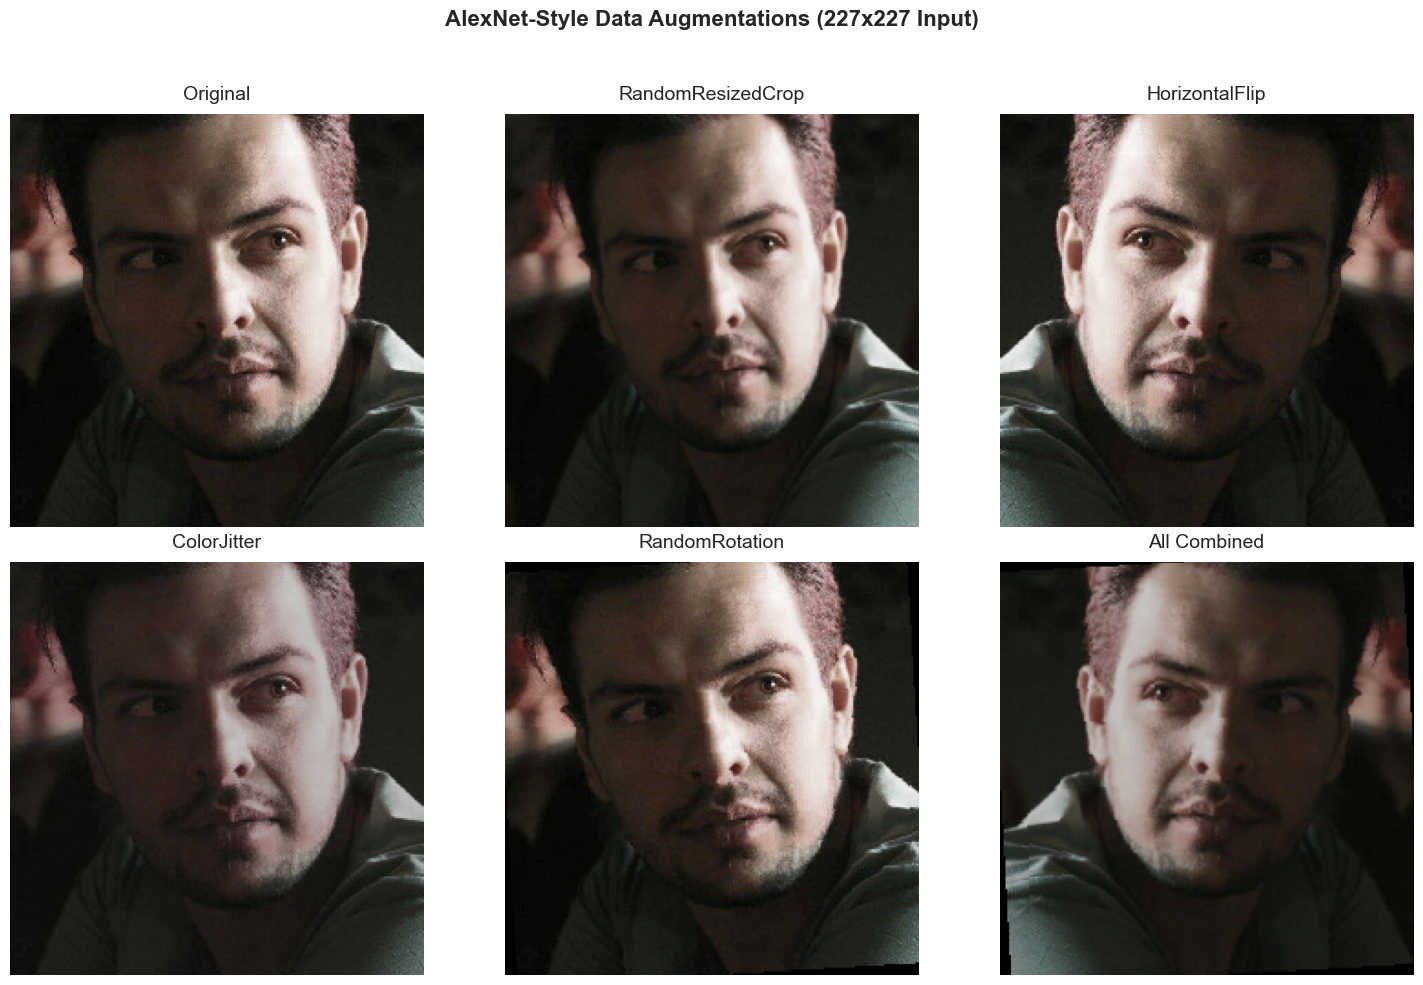

In [21]:
# ==========================================================================
# DATA AUGMENTATION VISUALIZATION FOR ALEXNET-STYLE PREPROCESSING
# =============================================================================
# This script demonstrates various image augmentations used in AlexNet (2012),
# which helped it achieve state-of-the-art results on ImageNet.
#
# Key AlexNet Augmentations:
# - Random crops from 256x256 → 227x227 (we simulate with 277 → 227 + crop)
# - Horizontal flips
# - Color jitter (PCA-based in original, here approximated with ColorJitter)
# - Training on smaller patches forces invariance to translation, scale, etc.
#
# Why augmentation?
# → Prevents overfitting
# → Increases effective training data
# → Improves robustness to real-world variations
#
# We'll visualize 6 versions: Original + 5 augmented variants
# =============================================================================

# -------------------------------
# 1. IMPORTS & DEPENDENCIES
# -------------------------------
import requests                          # For downloading image from URL
from io import BytesIO                   # To convert HTTP response bytes into file-like object
import matplotlib.pyplot as plt          # For plotting the augmented images
from torchvision.models import alexnet   # Define AlexNet (simplified for CIFAR-10, or use full version)
import torchvision
import torchvision.transforms as transforms  # PyTorch's powerful image transformation library
from PIL import Image                    # Python Imaging Library for opening images
import numpy as np                       # For tensor → numpy array conversion (for plotting)
import seaborn as sns
import random
import os                                      # For file/path operations (e.g., saving models)
import torch                                   # Core PyTorch library
import torch.nn as nn                          # Neural network layers
import torch.optim as optim                    # Optimizers (SGD, Adam, etc.)
import torch.nn.functional as F                # Functional operations (e.g., activation functions)
import torchvision.datasets as datasets         # Pre-built datasets (CIFAR10, MNIST, etc.)
from torch.utils.data import DataLoader, Subset, ConcatDataset  # Data loading utilities
from sklearn.metrics import confusion_matrix, f1_score, recall_score  # Evaluation metrics
from tqdm import tqdm                          # Progress bar for training loops

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using {device}")
# -------------------------------
# 2. CONFIGURATION CONSTANTS
# -------------------------------
IMAGE_DIM = 227  # AlexNet input size: 227x227 pixels (we crop to this from a larger image)
# Note: Original AlexNet training images were 256x256 → random crop to 227x227
# We use 277 to allow meaningful RandomResizedCrop (277 > 227 * 1.1)

# -------------------------------
# 3. DEFINE AUGMENTATION PIPELINES
# -------------------------------
# Each tuple: (name, transform_pipeline)
# We use `transforms.Compose` to chain multiple operations
augmentations = [
    # 1. Original (center crop only) - baseline
    ("Original", transforms.Compose([
        transforms.CenterCrop(IMAGE_DIM),     # Take center 227x227 patch
        transforms.ToTensor()                # Convert PIL Image → Tensor [C, H, W], values in [0,1]
    ])),

    # 2. Random Resized Crop - simulates random scale + crop (like AlexNet)
    ("RandomResizedCrop", transforms.Compose([
        transforms.RandomResizedCrop(
            IMAGE_DIM,
            scale=(0.9, 1.0),    # Crop between 90% and 100% of original area
            ratio=(0.9, 1.1)     # Allow slight aspect ratio change (close to square)
        ),
        transforms.ToTensor()
    ])),

    # 3. Horizontal Flip - AlexNet used p=0.5 random flip
    ("HorizontalFlip", transforms.Compose([
        transforms.CenterCrop(IMAGE_DIM),
        transforms.RandomHorizontalFlip(p=1.0),  # Force flip for demo (normally p=0.5)
        transforms.ToTensor()
    ])),

    # 4. Color Jitter - approximates AlexNet's PCA color augmentation
    ("ColorJitter", transforms.Compose([
        transforms.CenterCrop(IMAGE_DIM),
        transforms.ColorJitter(
            brightness=0.2,      # ±20% brightness
            contrast=0.2,        # ±20% contrast
            saturation=0.2,      # ±20% saturation
            hue=0.1              # ±10% hue (small to preserve semantics)
        ),
        transforms.ToTensor()
    ])),

    # 5. Random Rotation - not in original AlexNet, but common in modern augmentations
    ("RandomRotation", transforms.Compose([
        transforms.CenterCrop(IMAGE_DIM),
        transforms.RandomRotation(degrees=15),  # ±15 degrees
        transforms.ToTensor()
    ])),

    # 6. All Combined - realistic training augmentation (similar to AlexNet + extras)
    ("All Combined", transforms.Compose([
        transforms.RandomResizedCrop(IMAGE_DIM, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
        transforms.RandomHorizontalFlip(p=0.5),  # 50% chance (as in training)
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor()
    ]))
]

# -------------------------------
# 4. LOAD IMAGE FROM URL
# -------------------------------
image_url = 'https://drive.usercontent.google.com/u/0/uc?id=13h4o-42GKgwkARbhsDmXaViQ1hFUgk7r&export=download'

# Send HTTP GET request with a timeout and user-agent to avoid blocking
try:
    response = requests.get(image_url, timeout=10, headers={'User-Agent': 'Mozilla/5.0'})
    response.raise_for_status()  # Raise exception for bad status codes
except requests.exceptions.RequestException as e:
    raise SystemExit(f"Failed to download image: {e}")

# Open image from binary content using PIL
image = Image.open(BytesIO(response.content)).convert("RGB")  # Ensure RGB format

# Optional: Print original size for debugging
print(f"Original image size: {image.size} → will be cropped/resized to {IMAGE_DIM}x{IMAGE_DIM}")

# -------------------------------
# 5. APPLY AUGMENTATIONS & VISUALIZE
# -------------------------------
fig, axs = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 cols → 6 subplots
axs = axs.ravel()  # Flatten 2D array → 1D for easy indexing

for i, (title, aug) in enumerate(augmentations):
    # Apply the augmentation pipeline to the original PIL image
    augmented_tensor = aug(image)  # Output: Tensor [C, H, W] in [0,1]

    # Convert tensor from [C, H, W] → [H, W, C] for matplotlib
    augmented_np = augmented_tensor.permute(1, 2, 0).numpy()

    # Clip values to [0,1] in case of any overflow from jitter/rotation
    augmented_np = np.clip(augmented_np, 0, 1)

    # Display image
    axs[i].imshow(augmented_np)
    axs[i].set_title(title, fontsize=14, pad=10)
    axs[i].axis('off')  # Hide axes for cleaner look

# Hide unused subplots (in case we add more later)
for j in range(i + 1, len(axs)):
    axs[j].axis('off')

# -------------------------------
# 6. FINALIZE PLOT
# -------------------------------
plt.suptitle("AlexNet-Style Data Augmentations (227x227 Input)", 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit suptitle
plt.show()

In [4]:
# -------------------------------
#  HYPERPARAMETERS (Centralized for Easy Tuning)
# -------------------------------
class Config:
    BATCH_SIZE = 64
    NUM_WORKERS = 2 if device.type == 'cpu' else 4  # More workers on GPU
    LEARNING_RATE = 0.01
    WEIGHT_DECAY = 5e-4        # L2 regularization
    MOMENTUM = 0.9             # For SGD
    NUM_EPOCHS = 20
    VAL_SPLIT = 0.2            # 20% of training data for validation
    IMAGE_SIZE = 227           # AlexNet expects 227x227
    NUM_CLASSES = 10           # CIFAR-10 has 10 classes

config = Config()

In [5]:

model = alexnet(num_classes=config.NUM_CLASSES)
model = model.to(device)

# Print model summary
print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    model.parameters(),
    lr=config.LEARNING_RATE,
    momentum=config.MOMENTUM,
    weight_decay=config.WEIGHT_DECAY
)

## Why These Settings?

- **227×227 Input**: AlexNet was designed for this size.
- **ImageNet Normalization**: Even on CIFAR, using pre-trained stats helps convergence.
- **Validation Split**: Critical to monitor overfitting.
- **SGD + Momentum**: AlexNet used SGD with momentum = 0.9.
- **Weight Decay**: Prevents overfitting.

> **Note**: Full AlexNet has ~60M parameters — too big for CIFAR-10. In practice, use a **scaled-down version** or **transfer learning**.

In [7]:
# =============================================================================
# SCALED-DOWN ALEXNET FOR CIFAR-10
# =============================================================================
# Original AlexNet (2012):
# - Input: 227x227x3
# - 5 conv layers + 3 FC layers
# - ~60M parameters
# - Trained on ImageNet (1.2M images)
#
# This version:
# - Input: 32x32 → upsampled to 227x227 (or use smaller convs)
# - Fewer filters per layer
# - Same architectural tricks: ReLU, LRN, overlapping pool, dropout
# - ~1.3M parameters → trains fast on CPU/GPU
# - Great for teaching AlexNet concepts on small data
# =============================================================================


class AlexNetCIFAR(nn.Module):
    """
    Scaled-down AlexNet for CIFAR-10.
    Preserves key innovations:
    - ReLU activations
    - Local Response Normalization (LRN)
    - Overlapping MaxPooling (3x3, stride=2)
    - Dropout in FC layers
    """
    def __init__(self, num_classes=10):
        super(AlexNetCIFAR, self).__init__()
        
        # -------------------------------
        # Feature Extractor (Conv Layers)
        # -------------------------------
        self.features = nn.Sequential(
            # Conv1: 32x32x3 → 55x55x96
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),  # Reduced from 96 filters
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),  # LRN
            nn.MaxPool2d(kernel_size=3, stride=2),  # Overlapping pool

            # Conv2: 27x27x64 → 27x27x192
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),  # 13x13x192

            # Conv3: 13x13x192 → 13x13x384
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv4: 13x13x384 → 13x13x256
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv5: 13x13x256 → 13x13x256
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),  # Final pool → 6x6x256
        )
        
        # -------------------------------
        # Classifier (Fully Connected)
        # -------------------------------
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            
            nn.Linear(4096, num_classes),  # Final output
        )
        
        # Initialize weights (AlexNet used specific init)
        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)           # [B, 256, 6, 6]
        x = torch.flatten(x, 1)        # [B, 256*6*6]
        x = self.classifier(x)         # [B, 10]
        return x

    def _initialize_weights(self):
        """Initialize weights like the original AlexNet paper."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # Kaiming-like, but AlexNet used Gaussian with std=0.01
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                nn.init.constant_(m.bias, 1)  # Bias = 1 in FC layers 2,4

# -------------------------------
# Instantiate Model
# -------------------------------
model = AlexNetCIFAR(num_classes=10).to(device)

# Print model summary
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

AlexNetCIFAR(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): ReLU(inplace=True)
    (6): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inpl

## Scaled-Down AlexNet for CIFAR-10

### Why Scale Down?
- CIFAR-10 images are **32×32** → too small for original AlexNet
- Full AlexNet has **60M parameters** → overkill and slow
- This version keeps **all key ideas**:
  - ReLU
  - Local Response Normalization (LRN)
  - Overlapping pooling
  - Dropout
  - Large FC layers

### Input Pipeline Note
We **upsample CIFAR-10 from 32×32 → 227×227** using:
```python
transforms.Resize(256) → RandomCrop(227)

In [8]:

# -------------------------------
# 1. CORRECT TRANSFORMS
# -------------------------------
transform_train = transforms.Compose([
    transforms.Resize(224),                    # Crucial: 32 → 224 (AlexNet size)
    transforms.RandomCrop(224, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

transform_test = transforms.Compose([
    transforms.Resize(224),                    # Resize test images too!
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# -------------------------------
# 2. LOAD DATA WITH CORRECT TRANSFORMS
# -------------------------------
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

# -------------------------------
# 3. COMPACT & WORKING ALEXNET (1.3M params)
# -------------------------------
class AlexNetCIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNetCIFAR, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),   # 224 → 55
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),                  # 55 → 27
            
            nn.Conv2d(64, 192, kernel_size=5, padding=2),           # 27 → 27
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),                  # 27 → 13
            
            nn.Conv2d(192, 384, kernel_size=3, padding=1),          # 13 → 13
            nn.ReLU(inplace=True),
            
            nn.Conv2d(384, 256, kernel_size=3, padding=1),          # 13 → 13
            nn.ReLU(inplace=True),
            
            nn.Conv2d(256, 256, kernel_size=3, padding=1),          # 13 → 13
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),                  # 13 → 6
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = AlexNetCIFAR().to(device)
print(model)
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

# -------------------------------
# 4. LOSS + OPTIMIZER (Original AlexNet settings)
# -------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# -------------------------------
# 5. TRAINING LOOP (Now it WILL learn!)
# -------------------------------
def train():
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in tqdm(trainloader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(trainloader), 100. * correct / total

def test():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in tqdm(testloader, desc="Testing"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

# -------------------------------
# 6. TRAIN FOR 25 EPOCHS
# -------------------------------
# Store history during training (add these lists before the loop)
train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(1, 26):
    train_loss, train_acc = train()
    test_acc = test()
    scheduler.step()
    
    # Append to history
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

print("Training complete!")

AlexNetCIFAR(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=

Testing: 100%|██████████| 79/79 [01:24<00:00,  1.07s/it]


Epoch 01 | Train Loss: 1.9852 | Train Acc: 25.74% | Test Acc: 41.06%


Testing: 100%|██████████| 79/79 [00:53<00:00,  1.49it/s]


Epoch 02 | Train Loss: 1.3992 | Train Acc: 48.85% | Test Acc: 58.06%


...

Epoch 23 | Train Loss: 0.2034 | Train Acc: 93.12% | Test Acc: 86.86%


Testing: 100%|██████████| 79/79 [00:53<00:00,  1.48it/s]


Epoch 24 | Train Loss: 0.2044 | Train Acc: 92.98% | Test Acc: 86.95%


Testing: 100%|██████████| 79/79 [00:53<00:00,  1.48it/s]


Epoch 25 | Train Loss: 0.2032 | Train Acc: 93.07% | Test Acc: 86.89%
Training complete!


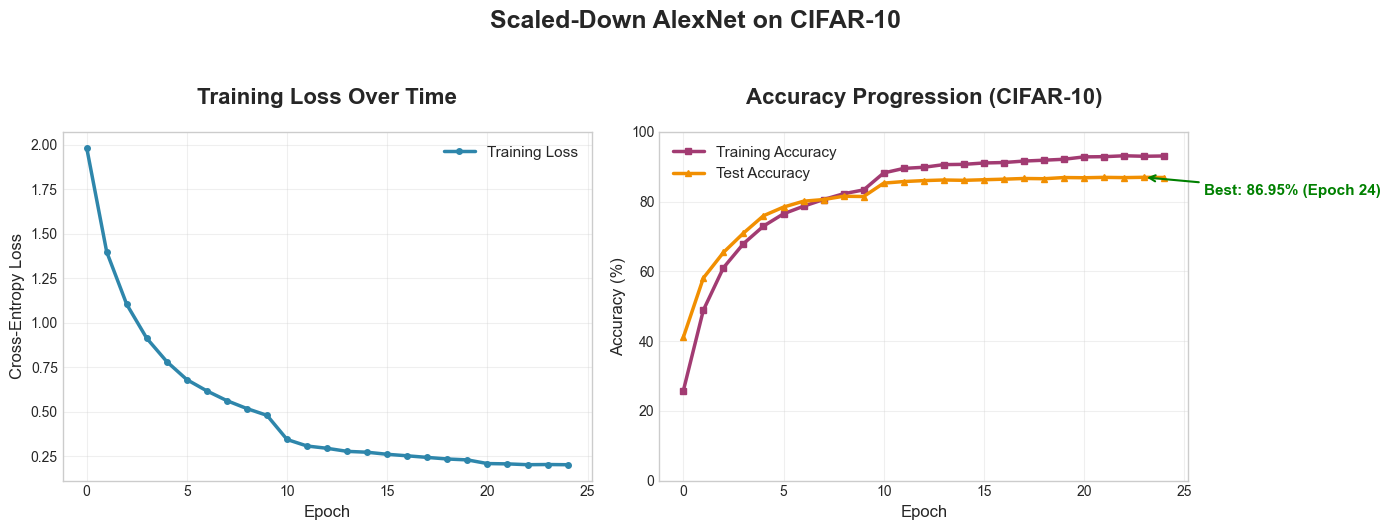


Final Test Accuracy: 86.89%
Best Test Accuracy:  86.95% at Epoch 24


In [9]:
# =============================================================================
# ACCURACY & LOSS PLOTS (Professional Style)
# =============================================================================

# === NOW PLOT! (Run this cell after training) ===
plt.style.use('seaborn-v0_8-whitegrid')  # Clean look
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss Plot ---
ax1.plot(train_losses, label='Training Loss', color='#2E86AB', linewidth=2.5, marker='o', markersize=4)
ax1.set_title('Training Loss Over Time', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# --- Accuracy Plot ---
ax2.plot(train_accuracies, label='Training Accuracy', color='#A23B72', linewidth=2.5, marker='s', markersize=4)
ax2.plot(test_accuracies, label='Test Accuracy', color='#F18F01', linewidth=2.5, marker='^', markersize=5)
ax2.set_title('Accuracy Progression (CIFAR-10)', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_ylim(0, 100)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Add best test accuracy annotation
best_epoch = test_accuracies.index(max(test_accuracies))
best_acc = max(test_accuracies)
ax2.annotate(f'Best: {best_acc:.2f}% (Epoch {best_epoch+1})',
             xy=(best_epoch, best_acc), xytext=(best_epoch + 3, best_acc - 5),
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
             fontsize=11, color='green', fontweight='bold')

plt.suptitle('Scaled-Down AlexNet on CIFAR-10', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Print final results
print(f"\nFinal Test Accuracy: {test_accuracies[-1]:.2f}%")
print(f"Best Test Accuracy:  {max(test_accuracies):.2f}% at Epoch {best_epoch + 1}")

Generating Predictions: 100%|██████████| 79/79 [01:05<00:00,  1.20it/s]


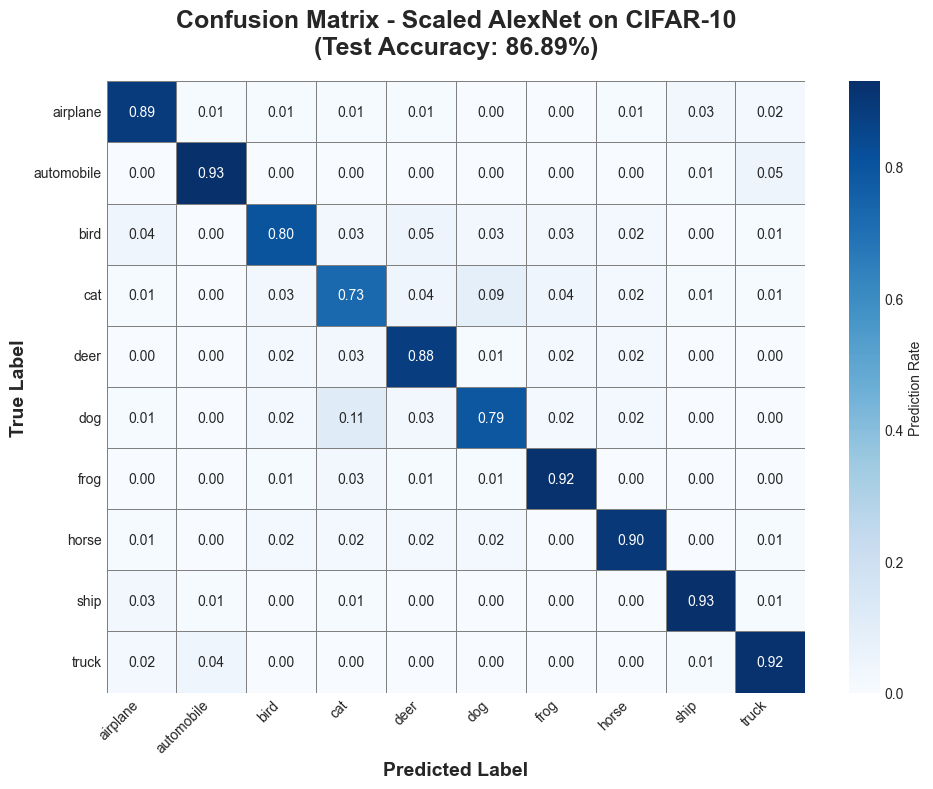


Per-class Accuracy (%):
  airplane     → 88.70%
  automobile   → 93.40%
  bird         → 79.50%
  cat          → 73.20%
  deer         → 87.80%
  dog          → 78.70%
  frog         → 92.30%
  horse        → 90.00%
  ship         → 92.90%
  truck        → 92.40%


In [10]:
# =============================================================================
# CONFUSION MATRIX HEATMAP (Best Model on Test Set)
# =============================================================================

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Re-evaluate the BEST model on test set and collect predictions
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(testloader, desc="Generating Predictions"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Normalize to percentages (optional but very informative)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_percent = np.round(cm_percent, 2)

# Find best test accuracy again (for title)
test_acc = 100. * np.trace(cm) / np.sum(cm)

# PLOT HEATMAP
plt.figure(figsize=(10, 8))
sns.heatmap(cm_percent, 
            annot=True,                     # Show numbers
            fmt='.2f',                      # 2 decimal places
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Prediction Rate'},
            linewidths=0.5,
            linecolor='gray')

plt.title(f'Confusion Matrix - Scaled AlexNet on CIFAR-10\n(Test Accuracy: {test_acc:.2f}%)', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Optional: Print per-class accuracy
print("\nPer-class Accuracy (%):")
for i, name in enumerate(class_names):
    class_acc = 100. * cm[i, i] / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
    print(f"  {name:12s} → {class_acc:5.2f}%")